#Install Library

In [ ]:
# !pip install sastrawi
# !pip install transformers torch
# !pip install feedparser pandas
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


#Import Library

In [ ]:
import pandas as pd
import requests
from google_play_scraper import reviews, Sort
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Google Playstore

In [ ]:
result, continuation_token = reviews(
    'com.apps.MyXL',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5000)
df_playstore = pd.DataFrame(result)
    #continuation_token=continuation_token

In [ ]:
df_playstore

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9c1f5a9d-461c-4c93-9024-1b7ea7f88707,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah 2 hari sinyalnya jelek bgt!,1,0,9.2.0,2026-07-05 05:32:19,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2023-10-12 23:00:14,9.2.0
1,d57d4055-4cae-4a5d-98d9-02108c9d73e1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah sering ditipu xl. aku udah beli paket di ...,5,0,9.3.0,2026-07-05 05:28:14,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-07-05 07:00:27,9.3.0
2,65e8fa3f-a28f-43d8-b7c1-759d22d8530c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan nya jelek sekali padahal bukan di hutan,1,0,9.3.0,2026-07-05 05:14:39,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-07-05 07:00:30,9.3.0
3,23a2e685-273d-42fd-9a3a-8b8c26996e36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sinyal ok,5,0,9.3.0,2026-07-05 05:08:03,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-07-05 07:00:31,9.3.0
4,c805a584-908b-4ef2-b099-c4431dab6682,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,btw dari 2019 mau nge tes pake XL enang selalu...,3,0,9.3.0,2026-07-05 05:00:53,"Hi Kak, mohon maaf atas kendala yang Kakak ala...",2026-07-05 07:00:33,9.3.0
...,...,...,...,...,...,...,...,...,...,...,...
4995,4f77e8b7-d117-4d2c-bcc9-bcc566ba9129,Rizky Almubarok,https://play-lh.googleusercontent.com/a/ACg8oc...,muantap jiga,5,0,None,2026-06-01 19:29:16,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-06-01 21:00:19,None
4996,edff218b-df80-46dd-863b-0fd73611cad4,DAVA SYAHRANI,https://play-lh.googleusercontent.com/a-/ALV-U...,bbrpa kali transaksi buat isi paket data tapi ...,2,0,9.2.0,2026-06-01 19:09:32,"Hi Kak, Maya mohon maaf ya atas kendalanya, yu...",2026-06-01 21:00:21,9.2.0
4997,9e2f9329-d243-4ab1-b202-006617a5d4cc,Hajija Moccy,https://play-lh.googleusercontent.com/a-/ALV-U...,App MyXL paling top👍👍👍,5,0,9.2.0,2026-06-01 18:59:10,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-06-01 19:00:08,9.2.0
4998,3745dc1f-b63d-4f0e-bc94-dfe570fa50f5,putri aryani,https://play-lh.googleusercontent.com/a/ACg8oc...,bad service...fitur chat maya gada yg respon.....,1,0,9.0.0,2026-06-01 18:38:53,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-06-01 19:00:12,9.0.0


#Sentiment Analysis

##Read Data

In [ ]:
df_playstore.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9c1f5a9d-461c-4c93-9024-1b7ea7f88707,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah 2 hari sinyalnya jelek bgt!,1,0,9.2.0,2026-07-05 05:32:19,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2023-10-12 23:00:14,9.2.0
1,d57d4055-4cae-4a5d-98d9-02108c9d73e1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah sering ditipu xl. aku udah beli paket di ...,5,0,9.3.0,2026-07-05 05:28:14,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-07-05 07:00:27,9.3.0
2,65e8fa3f-a28f-43d8-b7c1-759d22d8530c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan nya jelek sekali padahal bukan di hutan,1,0,9.3.0,2026-07-05 05:14:39,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-07-05 07:00:30,9.3.0
3,23a2e685-273d-42fd-9a3a-8b8c26996e36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sinyal ok,5,0,9.3.0,2026-07-05 05:08:03,"Hi Kak, terima kasih atas penilaiannya. Penila...",2026-07-05 07:00:31,9.3.0
4,c805a584-908b-4ef2-b099-c4431dab6682,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,btw dari 2019 mau nge tes pake XL enang selalu...,3,0,9.3.0,2026-07-05 05:00:53,"Hi Kak, mohon maaf atas kendala yang Kakak ala...",2026-07-05 07:00:33,9.3.0


In [ ]:
df = df_playstore[['content']].copy()

#Data Understanding (EDA Awal)

##Cek Missing Value & Duplicate

In [ ]:
df.isnull().sum()

,0
content,0


In [ ]:
df.duplicated().sum()

np.int64(206)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

##Visualisasi

###Distribusi Rating

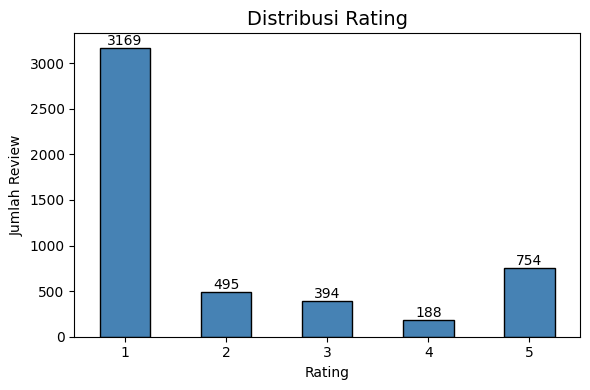

In [ ]:
rating = df_playstore['score'].value_counts().sort_index()

plt.figure(figsize=(6,4))
ax = rating.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribusi Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)

# Tambahkan jumlah di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

###Distribusi Panjang Review

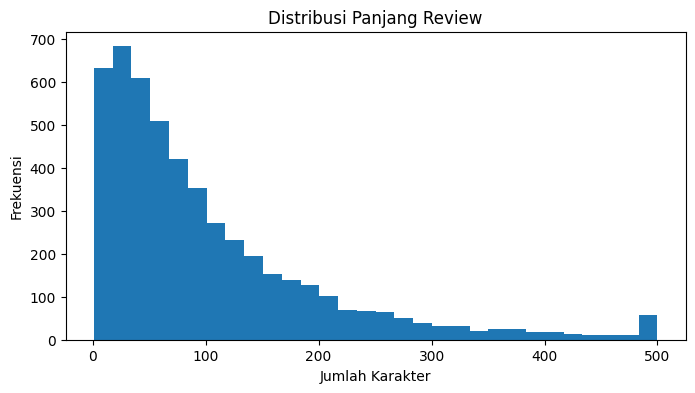

In [ ]:
df_playstore['review_length'] = df_playstore['content'].str.len()

plt.figure(figsize=(8,4))
plt.hist(df_playstore['review_length'], bins=30)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

###Top 10 Review Terbanyak

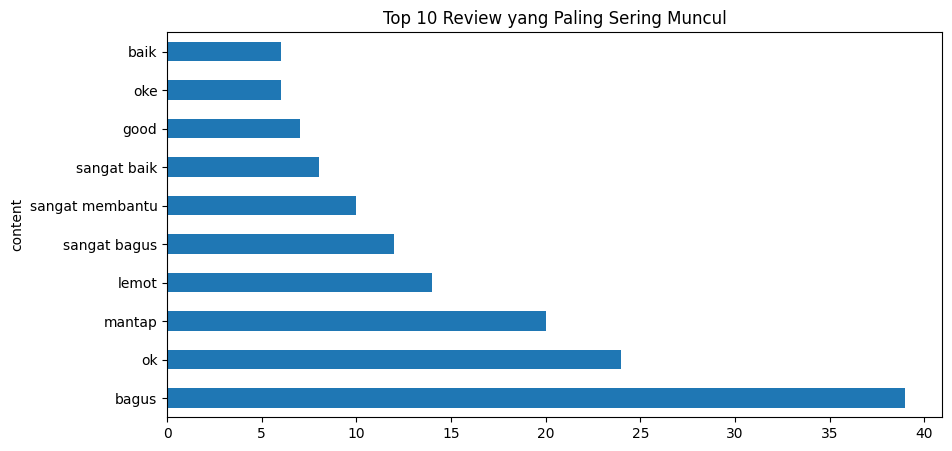

In [ ]:
top_review = df_playstore['content'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_review.plot(kind='barh')
plt.title('Top 10 Review yang Paling Sering Muncul')
plt.show()

#Data Preprocessing

In [ ]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # ganti titik menjadi spasi
    text = text.replace('.', ' ')

    # ganti underscore
    text = text.replace('_', ' ')

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        text,
        flags=re.UNICODE
    )

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaning'] = df['content'].apply(cleaning)

In [ ]:
df.head()

,content,cleaning
0,udah 2 hari sinyalnya jelek bgt!,udah hari sinyalnya jelek bgt
1,udah sering ditipu xl. aku udah beli paket di ...,udah sering ditipu xl aku udah beli paket di a...
2,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan
3,sinyal ok,sinyal ok
4,btw dari 2019 mau nge tes pake XL enang selalu...,btw dari mau nge tes pake XL enang selalu kend...


In [ ]:
df.tail()

,content,cleaning
4995,muantap jiga,muantap jiga
4996,bbrpa kali transaksi buat isi paket data tapi ...,bbrpa kali transaksi buat isi paket data tapi ...
4997,App MyXL paling top👍👍👍,App MyXL paling top
4998,bad service...fitur chat maya gada yg respon.....,bad service fitur chat maya gada yg respon isi...
4999,saya pakai paket bebas puas yang masa berlakun...,saya pakai paket bebas puas yang masa berlakun...


##Case Folding

In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
      return text.lower()
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,content,cleaning,case_folding
0,udah 2 hari sinyalnya jelek bgt!,udah hari sinyalnya jelek bgt,udah hari sinyalnya jelek bgt
1,udah sering ditipu xl. aku udah beli paket di ...,udah sering ditipu xl aku udah beli paket di a...,udah sering ditipu xl aku udah beli paket di a...
2,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan
3,sinyal ok,sinyal ok,sinyal ok
4,btw dari 2019 mau nge tes pake XL enang selalu...,btw dari mau nge tes pake XL enang selalu kend...,btw dari mau nge tes pake xl enang selalu kend...
5,"hari ini saya sudah membeli paket data, pembay...",hari ini saya sudah membeli paket data pembaya...,hari ini saya sudah membeli paket data pembaya...
6,luar biasa,luar biasa,luar biasa
7,lag,lag,lag
8,jaringan buruk xl ini haduh kuota dah mahal parah,jaringan buruk xl ini haduh kuota dah mahal parah,jaringan buruk xl ini haduh kuota dah mahal parah
9,ok,ok,ok


##Tokenize

In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens
df['tokenize'] = df['case_folding'].apply(tokenize)
df.head(10)

,content,cleaning,case_folding,tokenize,normalize,stopword,stemming,sentiment,sentiment_score
0,udah 2 hari sinyalnya jelek bgt!,udah hari sinyalnya jelek bgt,udah hari sinyalnya jelek bgt,"[udah, hari, sinyalnya, jelek, bgt]","[sudah, hari, sinyalnya, jelek, bangat]","[sinyalnya, jelek, bangat]",sinyal jelek bangat,negative,0.998038
1,udah sering ditipu xl. aku udah beli paket di ...,udah sering ditipu xl aku udah beli paket di a...,udah sering ditipu xl aku udah beli paket di a...,"[udah, sering, ditipu, xl, aku, udah, beli, pa...","[sudah, sering, ditipu, xl, aku, sudah, beli, ...","[ditipu, xl, beli, paket, apk, saldo, kepotong...",tipu xl beli paket apk saldo potong paket inte...,negative,0.744020
2,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,"[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, jelek, hutan]",jaring jelek hutan,negative,0.991094
3,sinyal ok,sinyal ok,sinyal ok,"[sinyal, ok]","[sinyal, ok]","[sinyal, ok]",sinyal ok,neutral,0.887274
4,btw dari 2019 mau nge tes pake XL enang selalu...,btw dari mau nge tes pake XL enang selalu kend...,btw dari mau nge tes pake xl enang selalu kend...,"[btw, dari, mau, nge, tes, pake, xl, enang, se...","[btw, dari, mau, nge, tes, pakai, xl, emang, s...","[tes, pakai, xl, kendala, registrasi, telepon,...",tes pakai xl kendala registrasi telepon sms sk...,neutral,0.890481
5,"hari ini saya sudah membeli paket data, pembay...",hari ini saya sudah membeli paket data pembaya...,hari ini saya sudah membeli paket data pembaya...,"[hari, ini, saya, sudah, membeli, paket, data,...","[hari, ini, saya, sudah, membeli, paket, data,...","[membeli, paket, data, pembayaran, mbanking, b...",beli paket data bayar mbanking hasil cek aplik...,neutral,0.863097
6,luar biasa,luar biasa,luar biasa,"[luar, biasa]","[luar, biasa]",[],,neutral,0.988005
7,lag,lag,lag,[lag],[lag],[lag],lag,positive,0.490658
8,jaringan buruk xl ini haduh kuota dah mahal parah,jaringan buruk xl ini haduh kuota dah mahal parah,jaringan buruk xl ini haduh kuota dah mahal parah,"[jaringan, buruk, xl, ini, haduh, kuota, dah, ...","[jaringan, buruk, xl, ini, haduh, kuota, dah, ...","[jaringan, buruk, xl, haduh, kuota, dah, mahal...",jaring buruk xl haduh kuota dah mahal parah,negative,0.999009
9,ok,ok,ok,[ok],[ok],[ok],ok,negative,0.993006


##Normalize Slang

In [ ]:
slang_dict = {
    'yg':'yang',
    'abiss':'habis',
    'bangett':'banget',
    'ad':'ada',
    'adaaa':'ada',
    'adaaaaaa':'ada',
    'pake':'pakai',
    'enang':'emang',
    'dg':'dengan',
    'dgn':'dengan',
    'bgn' :'bangun',
    'utk':'untuk',
    'sdh':'sudah',
    'udh':'sudah',
    'udah':'sudah',
    'blm':'belum',
    'sm':'sama',
    'krn':'karena',
    'dr':'dari',
    'trs':'terus',
    'lu' : 'kamu',
    'loe' : 'kamu',
    'lho' : 'kamu',
    'dpt':'dapat',
    'dapet':'dapat',
    'bkn':'bukan',
    'jd':'jadi',
    'jdi':'jadi',
    'bwt':'buat',
    'byr':'bayar',
    'pke':'pakai',
    'pkai':'pakai',
    'org':'orang',
    'ank':'anak',
    'ortu':'orang tua',
    'mrk':'mereka',
    'sy':'saya',
    'sya':'saya',
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',
    'aq':'aku',
    'gk':'tidak',
    'ga':'tidak',
    'gak':'tidak',
    'nggak':'tidak',
    'ngga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',
    'bgt':'banget',
    'bngt':'banget',
    'bnget':'banget',
    'jgn':'jangan',
    'jngn':'jangan',
    'hr':'hari',
    'hri':'hari',
    'thn':'tahun',
    'bln':'bulan',
    'byk':'banyak',
    'bnyk':'banyak',
    'sdkt':'sedikit',
    'mnrt':'menurut',
    'pdhl':'padahal',
    'klu':'kalau',
    'kalo':'kalau',
    'klo':'kalau',
    'kl':'kalau',
    'tp':'tapi',
    'tpi':'tapi',
    'bs':'bisa',
    'bsa':'bisa',
    'aja':'saja',
    'doang':'saja',
    'smoga':'semoga',
    'moga':'semoga',
    'kyk':'seperti',
    'cm':'cuma',
    'cmn':'cuma',
     "yg":"yang",
    "gk":"tidak",
    "ga":"tidak",
    "nggak":"tidak",
    "tdk":"tidak",
    "bgt":"bangat",
    "krn":"karena",
    "jd":"jadi",
    "pdhl":"padahal",
    "udah":"sudah",
    "sdh":"sudah",

    'bpk':'bapak',
    'pak':'bapak',
    'bu':'ibu',
    'goblk' : 'goblok'
}

def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df['normalize'] = df['tokenize'].apply(normalize_slang)

In [ ]:
df.head()

,content,cleaning,case_folding,tokenize,normalize,stopword
0,udah 2 hari sinyalnya jelek bgt!,udah hari sinyalnya jelek bgt,udah hari sinyalnya jelek bgt,"[udah, hari, sinyalnya, jelek, bgt]","[sudah, hari, sinyalnya, jelek, bangat]","[sinyalnya, jelek, bangat]"
1,udah sering ditipu xl. aku udah beli paket di ...,udah sering ditipu xl aku udah beli paket di a...,udah sering ditipu xl aku udah beli paket di a...,"[udah, sering, ditipu, xl, aku, udah, beli, pa...","[sudah, sering, ditipu, xl, aku, sudah, beli, ...","[ditipu, xl, beli, paket, apk, saldo, kepotong..."
2,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,"[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, jelek, hutan]"
3,sinyal ok,sinyal ok,sinyal ok,"[sinyal, ok]","[sinyal, ok]","[sinyal, ok]"
4,btw dari 2019 mau nge tes pake XL enang selalu...,btw dari mau nge tes pake XL enang selalu kend...,btw dari mau nge tes pake xl enang selalu kend...,"[btw, dari, mau, nge, tes, pake, xl, enang, se...","[btw, dari, mau, nge, tes, pakai, xl, emang, s...","[tes, pake, xl, kendala, registrasi, telepon, ..."


##Stopword Removal

In [ ]:
custom_stopwords = {
    'yg','aja','nya','nih','dong','btw','emang',
    'lah','mah','kok','gak','ga','nggak','nge',
    'udah','sdh','bgt','banget'}
stopword_id.update(custom_stopwords)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]
df['stopword'] = df['normalize'].apply(remove_stopwords)

In [ ]:
df.head()

,content,cleaning,case_folding,tokenize,normalize,stopword
0,udah 2 hari sinyalnya jelek bgt!,udah hari sinyalnya jelek bgt,udah hari sinyalnya jelek bgt,"[udah, hari, sinyalnya, jelek, bgt]","[sudah, hari, sinyalnya, jelek, bangat]","[sinyalnya, jelek, bangat]"
1,udah sering ditipu xl. aku udah beli paket di ...,udah sering ditipu xl aku udah beli paket di a...,udah sering ditipu xl aku udah beli paket di a...,"[udah, sering, ditipu, xl, aku, udah, beli, pa...","[sudah, sering, ditipu, xl, aku, sudah, beli, ...","[ditipu, xl, beli, paket, apk, saldo, kepotong..."
2,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,jaringan nya jelek sekali padahal bukan di hutan,"[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, nya, jelek, sekali, padahal, bukan,...","[jaringan, jelek, hutan]"
3,sinyal ok,sinyal ok,sinyal ok,"[sinyal, ok]","[sinyal, ok]","[sinyal, ok]"
4,btw dari 2019 mau nge tes pake XL enang selalu...,btw dari mau nge tes pake XL enang selalu kend...,btw dari mau nge tes pake xl enang selalu kend...,"[btw, dari, mau, nge, tes, pake, xl, enang, se...","[btw, dari, mau, nge, tes, pakai, xl, emang, s...","[tes, pakai, xl, kendala, registrasi, telepon,..."


##Stemming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)
df['stemming'] = df['stopword'].apply(stemming)

In [ ]:
df[df['stemming'].str.contains('adabalasan', na=False)][
    ['content','cleaning','normalize','stopword','stemming']
]

,content,cleaning,normalize,stopword,stemming
1409,"Sinyal suka ilang,bonus kadang harus chat maya...",Sinyal suka ilangbonus kadang harus chat maya ...,"[sinyal, suka, ilangbonus, kadang, harus, chat...","[sinyal, suka, ilangbonus, kadang, chat, maya,...",sinyal suka ilangbonus kadang chat maya biar a...


In [ ]:
# COBA COBA CEK
df[df['stemming'].str.contains('adabalasan', na=False)][['content','cleaning','stemming']]

,content,cleaning,stemming
1409,"Sinyal suka ilang,bonus kadang harus chat maya...",Sinyal suka ilangbonus kadang harus chat maya ...,sinyal suka ilangbonus kadang chat maya biar a...


#Sentiment Labeling

In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model = "w11wo/indonesian-roberta-base-sentiment-classifier")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [ ]:
df[['stemming','sentiment']].head(20)

,stemming,sentiment
0,sinyal jelek bangat,negative
1,tipu xl beli paket apk saldo potong paket inte...,negative
2,jaring jelek hutan,negative
3,sinyal ok,neutral
4,tes pakai xl kendala registrasi telepon sms sk...,neutral
5,beli paket data bayar mbanking hasil cek aplik...,neutral
6,,neutral
7,lag,positive
8,jaring buruk xl haduh kuota dah mahal parah,negative
9,ok,negative


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,3064
neutral,1341
positive,389


#EDA

##1. Distribusi Sentimen

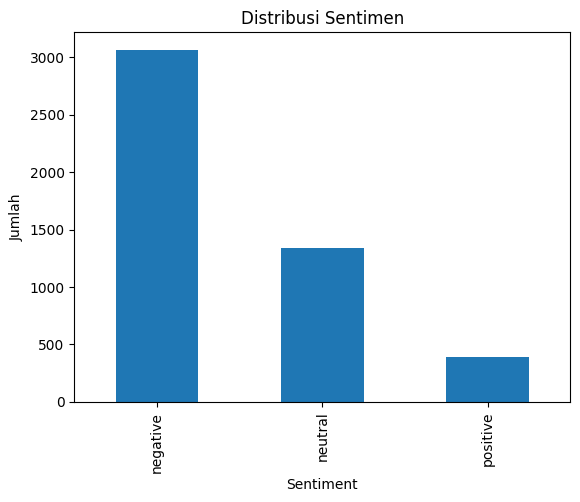

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='bar',
    xlabel='Sentiment',
    ylabel='Jumlah',
    title='Distribusi Sentimen'
)

plt.show()

<Axes: ylabel='count'>

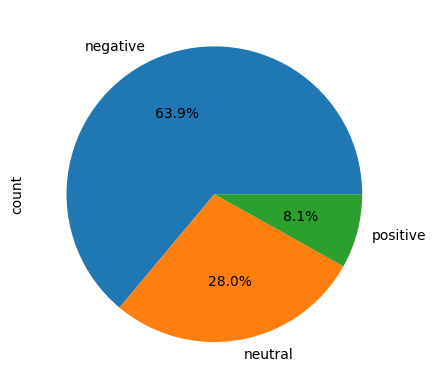

In [ ]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

##2. WordCloud Positive

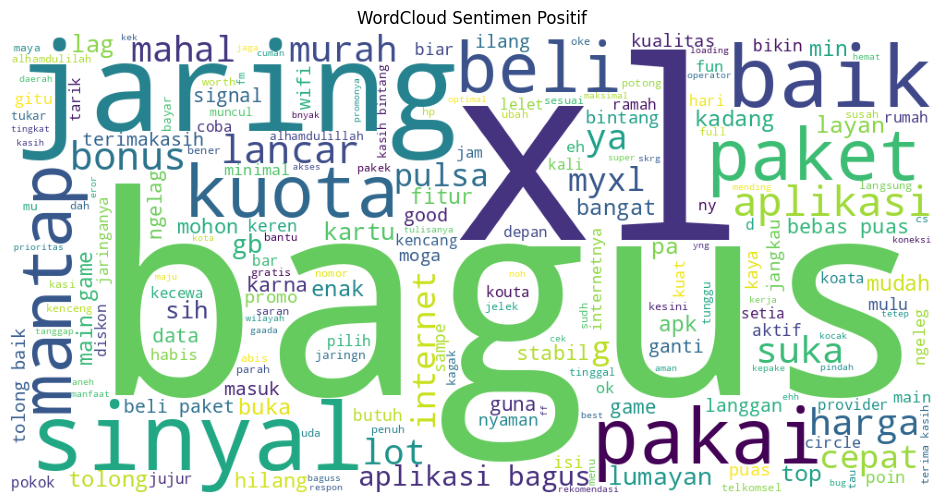

In [ ]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=="positive"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Positif")
plt.show()

##3. WordCloud Negative

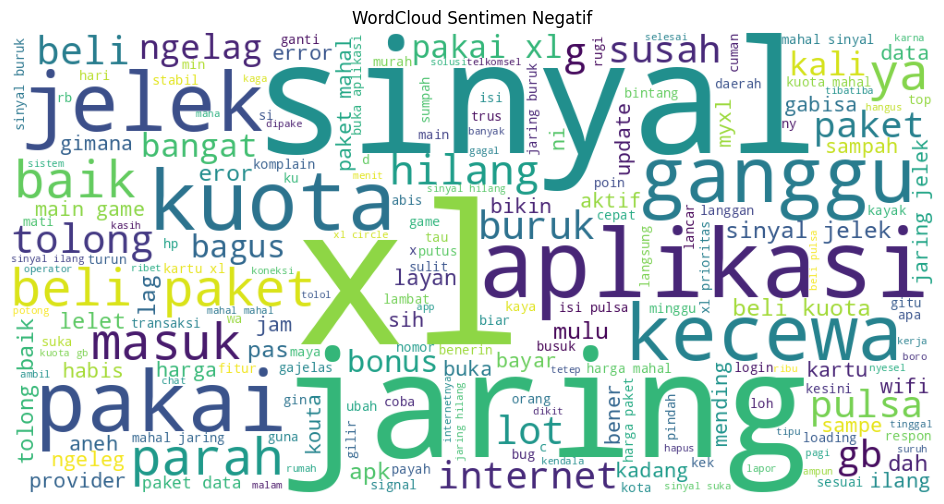

In [ ]:
negative_text = " ".join(
    df[df['sentiment']=="negative"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Negatif")
plt.show()

##4. Top Frequent Words

In [ ]:
from collections import Counter

words = ' '.join(df['stemming']).split()

Counter(words).most_common(20)

[('xl', 1874),
 ('jaring', 1317),
 ('sinyal', 1184),
 ('paket', 935),
 ('beli', 897),
 ('kuota', 877),
 ('aplikasi', 692),
 ('pakai', 646),
 ('baik', 496),
 ('pulsa', 494),
 ('tolong', 493),
 ('jelek', 486),
 ('mahal', 480),
 ('lot', 383),
 ('hilang', 379),
 ('gb', 357),
 ('bagus', 330),
 ('masuk', 320),
 ('internet', 304),
 ('g', 303)]

In [ ]:
import pandas as pd

freq = pd.DataFrame(
    Counter(words).most_common(20),
    columns=['word','count']
)

<Axes: xlabel='word'>

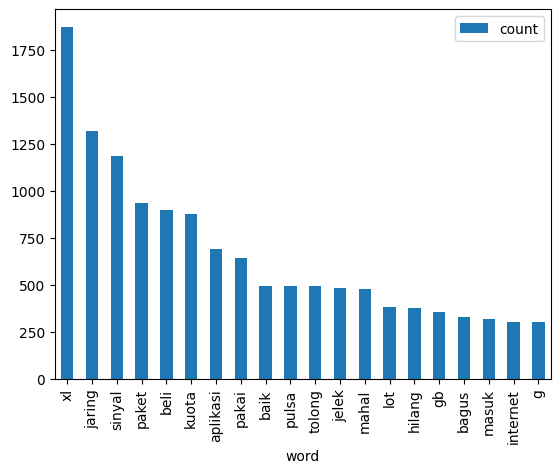

In [ ]:
freq.plot.bar(
    x='word',
    y='count'
)

##5. Bigram

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    ngram_range=(2,2)
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2))

X = cv.fit_transform(df['stemming'])

In [ ]:
bigrams = cv.get_feature_names_out()

In [ ]:
counts = X.sum(axis=0).A1

In [ ]:
import pandas as pd

bigram_df = pd.DataFrame({
    'Bigram': bigrams,
    'Frequency': counts
})

bigram_df = bigram_df.sort_values(by='Frequency', ascending=False)

bigram_df.head(20)

,Bigram,Frequency
2907,beli paket,319
2868,beli kuota,176
25614,tolong baik,169
19494,pakai xl,161
25767,top up,159
17605,my xl,156
15705,main game,130
23437,sinyal jelek,119
19580,paket data,119
10481,jaring jelek,89


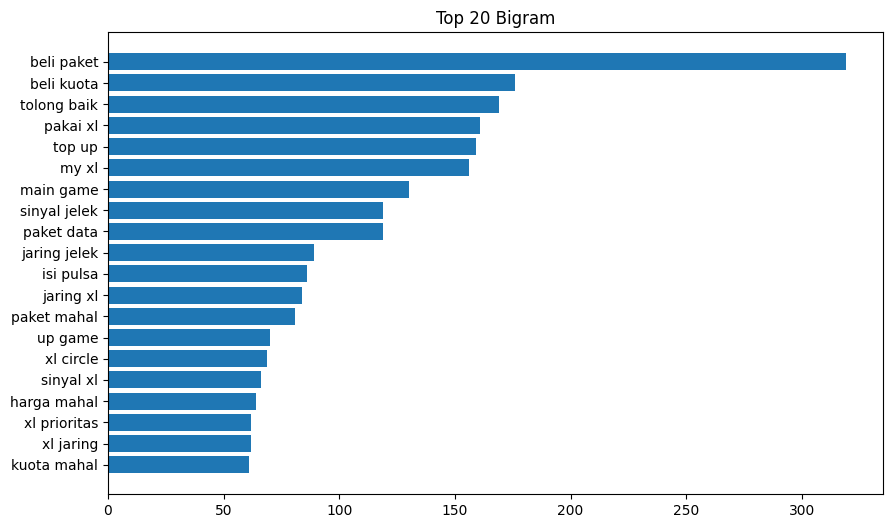

In [ ]:
import matplotlib.pyplot as plt

top20 = bigram_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Bigram'], top20['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Bigram")
plt.show()

#Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Transformasi data teks menjadi fitur numerik
X = tfidf.fit_transform(df['stemming'])

# Label
y = df['sentiment']

# Menampilkan ukuran hasil transformasi
print("Shape TF-IDF:", X.shape)

# Menampilkan beberapa fitur
print(tfidf.get_feature_names_out()[:20])

Shape TF-IDF: (4794, 5000)
['aamiin' 'abai' 'abal' 'abis' 'abiss' 'acara' 'account' 'acivement'
 'activate' 'active' 'ad' 'ada' 'adaaa' 'adaaaaaa' 'adabalasan' 'adad'
 'adadasar' 'adahilang' 'adain' 'adainternet']


##Split Data

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(df['stemming'], df['sentiment'],

                                                                    test_size=0.2, random_state=42)

In [ ]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

##Naive Bayes

##Decision Tree

##Random Forest

##AdaBoost

##Logistic Regresi